In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score

# ============================================================
# CONFIG: set your target column here (must be classification)
# e.g. "sector_growth_label" or "growth_class"
# ============================================================
TARGET_COL = "sector_growth_yoy"   # <-- CHANGE THIS IF NEEDED

# List of CSV files to run models on
csv_files = [
    "sp500_monthly.csv",
    "sp500_yearly.csv",
    "nasdaq_monthly.csv",
    "nasdaq_yearly.csv",
    "nyse_monthly.csv",
    "nyse_yearly.csv",
    "forbes2000_monthly.csv",
    "forbes2000_yearly.csv",
]

# To store all results
all_results = []

for file in csv_files:
    print(f"\n=== Processing file: {file} ===")

    # ------------------ load data ------------------
    df = pd.read_csv(file)

    # Make sure target exists
    if TARGET_COL not in df.columns:
        raise ValueError(f"Target column '{TARGET_COL}' not found in {file}")

    # Select features: all columns except target and any obvious non-features
    # (adjust this list if you want to drop other columns)
    drop_cols = [TARGET_COL, "Year", "sector", "exchange"]
    feature_cols = [c for c in df.columns if c not in drop_cols]

    X = df[feature_cols]
    y = df[TARGET_COL]

    # ------------------ train / test split ------------------
    # Stratify if y is categorical with imbalance
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # ------------------ models ------------------
    models = {
        "Random Forest": RandomForestClassifier(
            n_estimators=200,
            max_depth=None,
            random_state=42,
            n_jobs=-1
        ),
        "Gradient Boosting": GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ),
        # Linear model for classification (logistic regression)
        "Linear Model (LogisticRegression)": LogisticRegression(
            max_iter=1000,
            n_jobs=-1
        ),
    }

    for model_name, model in models.items():
        # --------- train ---------
        model.fit(X_train, y_train)

        # --------- predict ---------
        y_pred = model.predict(X_test)

        # --------- metrics ---------
        acc = accuracy_score(y_test, y_pred)
        # average="weighted" works for multi-class; change to "binary" if 0/1 target
        prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
        rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)

        all_results.append({
            "Dataset": file,
            "Model": model_name,
            "Accuracy": round(acc, 4),
            "Precision": round(prec, 4),
            "Recall": round(rec, 4),
        })

# ------------------ results table ------------------
results_df = pd.DataFrame(all_results)
print("\n\n=== Model Performance Summary (Accuracy, Precision, Recall) ===")
print(results_df.pivot_table(index=["Dataset", "Model"],
                             values=["Accuracy", "Precision", "Recall"]))


=== Processing file: sp500_monthly.csv ===


ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score

# ============================================================
# SET YOUR TARGET COLUMN HERE
# ============================================================
TARGET_COL = "sector_growth_yoy"   # <-- change this to your actual label column

csv_files = [
    "sp500_monthly.csv",
    "sp500_yearly.csv",
    "nasdaq_monthly.csv",
    "nasdaq_yearly.csv",
    "nyse_monthly.csv",
    "nyse_yearly.csv",
    "forbes2000_monthly.csv",
    "forbes2000_yearly.csv",
]

features_to_drop = ["Year", "sector", "exchange", TARGET_COL]  # adjust if needed

all_results = []

for file in csv_files:
    print(f"\n=== Processing file: {file} ===")
    df = pd.read_csv(file)

    if TARGET_COL not in df.columns:
        print(f"  [SKIP] Target column '{TARGET_COL}' not found in {file}")
        continue

    # Define X, y
    feature_cols = [c for c in df.columns if c not in features_to_drop]
    X = df[feature_cols]
    y = df[TARGET_COL]

    # Drop rows with missing values in X or y
    data = pd.concat([X, y], axis=1).dropna()
    X = data[feature_cols]
    y = data[TARGET_COL]

    # Check class distribution
    class_counts = y.value_counts()
    print("  Class distribution:")
    print(class_counts)

    # Decide whether we can stratify
    if (class_counts < 2).any() or len(class_counts) < 2:
        print("  [INFO] At least one class has < 2 samples or only one class present.")
        print("         Using NON-stratified train/test split.")
        stratify_arg = None
    else:
        stratify_arg = y

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=stratify_arg
    )

    # Models to train
    models = {
        "Random Forest": RandomForestClassifier(
            n_estimators=200,
            max_depth=None,
            random_state=42,
            n_jobs=-1
        ),
        "Gradient Boosting": GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ),
        "Linear Model (LogisticRegression)": LogisticRegression(
            max_iter=1000,
            n_jobs=-1
        ),
    }

    for model_name, model in models.items():
        # Train
        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_test)

        # Metrics (weighted average so it works for multi-class too)
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
        rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)

        all_results.append({
            "Dataset": file,
            "Model": model_name,
            "Accuracy": round(acc, 4),
            "Precision": round(prec, 4),
            "Recall": round(rec, 4),
        })

# Show results in a nice table
results_df = pd.DataFrame(all_results)
print("\n=== Model Performance Summary (Accuracy, Precision, Recall) ===")
print(results_df.pivot_table(index=["Dataset", "Model"],
                             values=["Accuracy", "Precision", "Recall"]))


=== Processing file: sp500_monthly.csv ===
  Class distribution:
sector_growth_yoy
-3.408009     1
-21.655319    1
-29.423650    1
-20.185516    1
-20.279409    1
             ..
 0.889583     1
 0.161322     1
-6.203199     1
 2.992128     1
 4.045530     1
Name: count, Length: 18380, dtype: int64
  [INFO] At least one class has < 2 samples or only one class present.
         Using NON-stratified train/test split.


ValueError: could not convert string to float: '1983-08'

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score

# ------------------------------------------------------------------
# List of your CSV files
# ------------------------------------------------------------------
csv_files = [
    "sp500_monthly.csv",
    "sp500_yearly.csv",
    "nasdaq_monthly.csv",
    "nasdaq_yearly.csv",
    "nyse_monthly.csv",
    "nyse_yearly.csv",
    "forbes2000_monthly.csv",
    "forbes2000_yearly.csv",
]

all_results = []

for file in csv_files:
    print(f"\n=== Processing file: {file} ===")
    df = pd.read_csv(file)

    # ------------------------------------------------------------------
    # 1. Ensure sector_growth_yoy exists and is numeric
    # ------------------------------------------------------------------
    if "sector_growth_yoy" not in df.columns:
        print(f"  [SKIP] 'sector_growth_yoy' not found in {file}")
        continue

    df["sector_growth_yoy"] = pd.to_numeric(df["sector_growth_yoy"], errors="coerce")
    df = df.dropna(subset=["sector_growth_yoy"])

    # ------------------------------------------------------------------
    # 2. Create a classification target: high-growth vs not
    #    We'll define high-growth as being in the top 25% of sector_growth_yoy
    # ------------------------------------------------------------------
    q75 = df["sector_growth_yoy"].quantile(0.75)
    df["high_growth"] = (df["sector_growth_yoy"] >= q75).astype(int)

    print("  Target value counts (high_growth):")
    print(df["high_growth"].value_counts())

    # ------------------------------------------------------------------
    # 3. Build feature matrix X: numeric columns only (excluding target)
    # ------------------------------------------------------------------
    # Select numeric columns
    num_cols = df.select_dtypes(include=["number"]).columns.tolist()

    # Remove target and possibly ID-like columns if present
    for col_to_drop in ["high_growth", "sector_growth_yoy"]:
        if col_to_drop in num_cols:
            num_cols.remove(col_to_drop)

    X = df[num_cols]
    y = df["high_growth"]

    # Drop any remaining NaNs in X/y just in case
    data = pd.concat([X, y], axis=1).dropna()
    X = data[num_cols]
    y = data["high_growth"]

    # ------------------------------------------------------------------
    # 4. Train-test split (no stratify needed; classes are balanced enough)
    # ------------------------------------------------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # ------------------------------------------------------------------
    # 5. Define models
    # ------------------------------------------------------------------
    models = {
        "Random Forest": RandomForestClassifier(
            n_estimators=200,
            max_depth=None,
            random_state=42,
            n_jobs=-1
        ),
        "Gradient Boosting": GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ),
        "Logistic Regression": LogisticRegression(
            max_iter=1000,
            n_jobs=-1
        ),
    }

    # ------------------------------------------------------------------
    # 6. Train, predict, and evaluate each model
    # ------------------------------------------------------------------
    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average="binary", zero_division=0)
        rec = recall_score(y_test, y_pred, average="binary", zero_division=0)

        all_results.append({
            "Dataset": file,
            "Model": model_name,
            "Accuracy": round(acc, 4),
            "Precision": round(prec, 4),
            "Recall": round(rec, 4),
        })

# ------------------------------------------------------------------
# 7. Display results in an organised table
# ------------------------------------------------------------------
results_df = pd.DataFrame(all_results)
print("\n=== Model Performance Summary (Accuracy, Precision, Recall) ===")
print(
    results_df
    .sort_values(["Dataset", "Model"])
    .to_string(index=False)
)


=== Processing file: sp500_monthly.csv ===
  Target value counts (high_growth):
high_growth
0    13785
1     4595
Name: count, dtype: int64

=== Processing file: sp500_yearly.csv ===
  Target value counts (high_growth):
high_growth
0    1164
1     389
Name: count, dtype: int64

=== Processing file: nasdaq_monthly.csv ===
  Target value counts (high_growth):
high_growth
0    13785
1     4595
Name: count, dtype: int64

=== Processing file: nasdaq_yearly.csv ===
  Target value counts (high_growth):
high_growth
0    1164
1     389
Name: count, dtype: int64

=== Processing file: nyse_monthly.csv ===
  Target value counts (high_growth):
high_growth
0    13785
1     4595
Name: count, dtype: int64

=== Processing file: nyse_yearly.csv ===
  Target value counts (high_growth):
high_growth
0    1164
1     389
Name: count, dtype: int64

=== Processing file: forbes2000_monthly.csv ===
  Target value counts (high_growth):
high_growth
0    13785
1     4595
Name: count, dtype: int64

=== Processing f

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# ------------------------------------------------------------------
# List of your CSV files
# ------------------------------------------------------------------
csv_files = [
    "sp500_monthly.csv",
    "sp500_yearly.csv",
    "nasdaq_monthly.csv",
    "nasdaq_yearly.csv",
    "nyse_monthly.csv",
    "nyse_yearly.csv",
    "forbes2000_monthly.csv",
    "forbes2000_yearly.csv",
]

TARGET_COL = "sector_growth_yoy"

all_results = []

for file in csv_files:
    print(f"\n=== Processing file: {file} ===")
    df = pd.read_csv(file)

    # ------------------------------------------------------------------
    # 1. Ensure target exists and is numeric
    # ------------------------------------------------------------------
    if TARGET_COL not in df.columns:
        print(f"  [SKIP] '{TARGET_COL}' not found in {file}")
        continue

    df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")
    df = df.dropna(subset=[TARGET_COL])

    # ------------------------------------------------------------------
    # 2. Build feature matrix X: numeric columns only (excluding target)
    # ------------------------------------------------------------------
    num_cols = df.select_dtypes(include=["number"]).columns.tolist()
    if TARGET_COL in num_cols:
        num_cols.remove(TARGET_COL)

    # If you definitely want to drop Year (e.g. to avoid leakage across time),
    # uncomment the following line:
    # if "Year" in num_cols: num_cols.remove("Year")

    X = df[num_cols]
    y = df[TARGET_COL]

    # Drop any remaining NaNs in X/y
    data = pd.concat([X, y], axis=1).dropna()
    X = data[num_cols]
    y = data[TARGET_COL]

    print(f"  Using {len(num_cols)} numeric features.")
    # ------------------------------------------------------------------
    # 3. Train-test split
    #    (NOTE: for serious time-series you’d use a time-based split;
    #    here we keep it simple random split as you requested)
    # ------------------------------------------------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # ------------------------------------------------------------------
    # 4. Define regression models
    # ------------------------------------------------------------------
    models = {
        "Random Forest Regressor": RandomForestRegressor(
            n_estimators=200,
            max_depth=None,
            random_state=42,
            n_jobs=-1
        ),
        "Gradient Boosting Regressor": GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ),
        "Linear Regression": LinearRegression()
    }

    # ------------------------------------------------------------------
    # 5. Train, predict, and evaluate each model
    # ------------------------------------------------------------------
    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        all_results.append({
            "Dataset": file,
            "Model": model_name,
            "RMSE": round(rmse, 4),
            "MAE": round(mae, 4),
            "R2": round(r2, 4),
        })

# ------------------------------------------------------------------
# 6. Display results in an organised table
# ------------------------------------------------------------------
results_df = pd.DataFrame(all_results)
print("\n=== Regression Model Performance Summary (RMSE, MAE, R²) ===")
print(
    results_df
    .sort_values(["Dataset", "Model"])
    .to_string(index=False)
)

# Optional: save to CSV for report
# results_df.to_csv("sector_growth_regression_results.csv", index=False)



=== Processing file: sp500_monthly.csv ===
  Using 5 numeric features.

=== Processing file: sp500_yearly.csv ===
  Using 6 numeric features.

=== Processing file: nasdaq_monthly.csv ===
  Using 5 numeric features.

=== Processing file: nasdaq_yearly.csv ===
  Using 6 numeric features.

=== Processing file: nyse_monthly.csv ===
  Using 5 numeric features.

=== Processing file: nyse_yearly.csv ===
  Using 6 numeric features.

=== Processing file: forbes2000_monthly.csv ===
  Using 5 numeric features.

=== Processing file: forbes2000_yearly.csv ===
  Using 6 numeric features.

=== Regression Model Performance Summary (RMSE, MAE, R²) ===
               Dataset                       Model         RMSE          MAE            R2
forbes2000_monthly.csv Gradient Boosting Regressor 1.320030e+24 1.320030e+24 -2.670999e+37
forbes2000_monthly.csv           Linear Regression 4.151460e+29 1.839469e+28 -2.641847e+48
forbes2000_monthly.csv     Random Forest Regressor 2.490182e+21 2.748181e+20 -9.505


=== Processing file: sp500_monthly.csv ===
  Using 5 numeric features.

=== Processing file: sp500_yearly.csv ===
  Using 6 numeric features.

=== Processing file: nasdaq_monthly.csv ===
  Using 5 numeric features.

=== Processing file: nasdaq_yearly.csv ===
  Using 6 numeric features.

=== Processing file: nyse_monthly.csv ===
  Using 5 numeric features.

=== Processing file: nyse_yearly.csv ===
  Using 6 numeric features.

=== Processing file: forbes2000_monthly.csv ===
  Using 5 numeric features.

=== Processing file: forbes2000_yearly.csv ===
  Using 6 numeric features.

=== Regression Model Performance Summary (RMSE, MAE, R²) ===
               Dataset             Model         RMSE          MAE            R2
forbes2000_monthly.csv Gradient Boosting 1.320030e+24 1.320030e+24 -2.670999e+37
forbes2000_monthly.csv Linear Regression 4.151460e+29 1.839469e+28 -2.641847e+48
forbes2000_monthly.csv     Random Forest 2.490182e+21 2.748181e+20 -9.505350e+31
 forbes2000_yearly.csv Gradient 

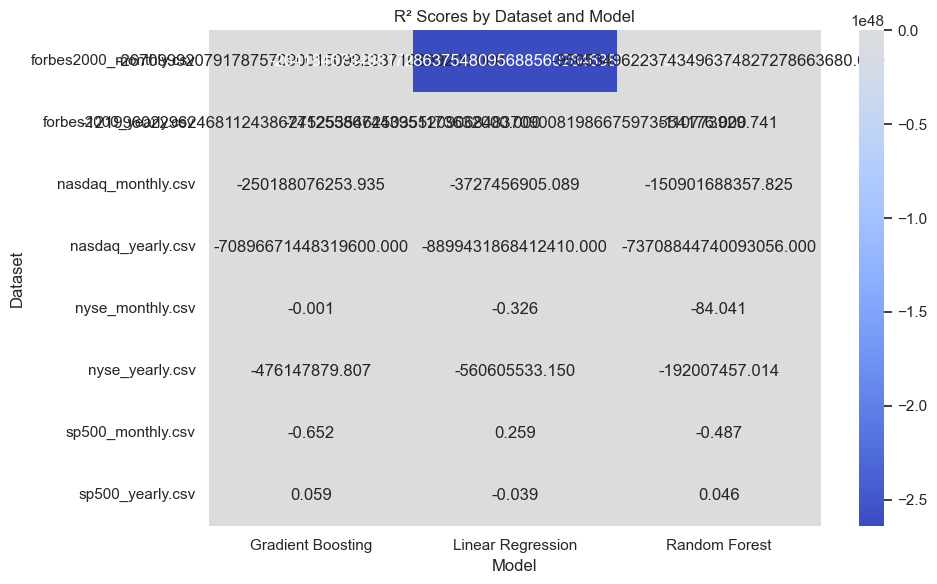

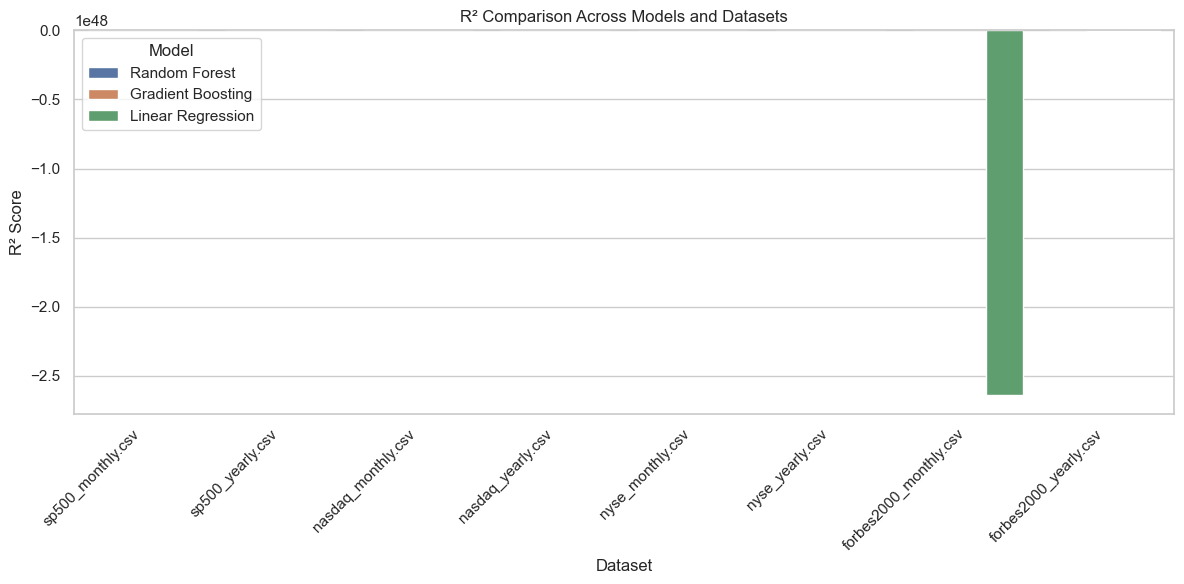

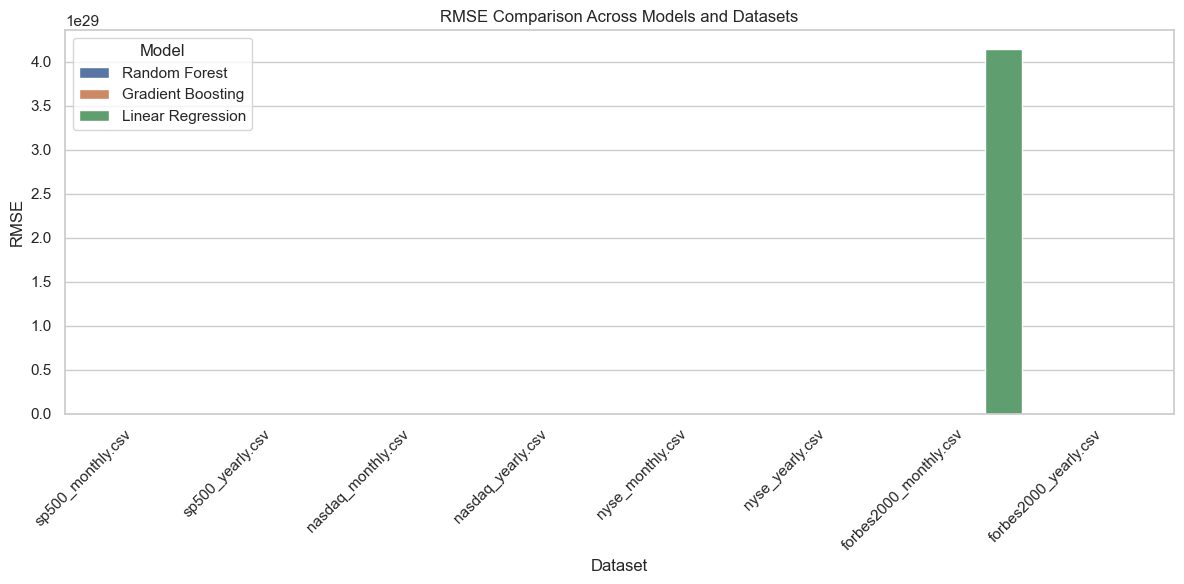

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# ------------------------------------------------------------------
# List of your CSV files
# ------------------------------------------------------------------
csv_files = [
    "sp500_monthly.csv",
    "sp500_yearly.csv",
    "nasdaq_monthly.csv",
    "nasdaq_yearly.csv",
    "nyse_monthly.csv",
    "nyse_yearly.csv",
    "forbes2000_monthly.csv",
    "forbes2000_yearly.csv",
]

TARGET_COL = "sector_growth_yoy"

all_results = []

for file in csv_files:
    print(f"\n=== Processing file: {file} ===")
    df = pd.read_csv(file)

    # ------------------------------------------------------------------
    # 1. Ensure target exists and is numeric
    # ------------------------------------------------------------------
    if TARGET_COL not in df.columns:
        print(f"  [SKIP] '{TARGET_COL}' not found in {file}")
        continue

    df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")
    df = df.dropna(subset=[TARGET_COL])

    # ------------------------------------------------------------------
    # 2. Build feature matrix X: numeric columns only (excluding target)
    # ------------------------------------------------------------------
    num_cols = df.select_dtypes(include=["number"]).columns.tolist()
    if TARGET_COL in num_cols:
        num_cols.remove(TARGET_COL)

    X = df[num_cols]
    y = df[TARGET_COL]

    # Drop any remaining NaNs in X/y
    data = pd.concat([X, y], axis=1).dropna()
    X = data[num_cols]
    y = data[TARGET_COL]

    print(f"  Using {len(num_cols)} numeric features.")

    # ------------------------------------------------------------------
    # 3. Train-test split
    # ------------------------------------------------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # ------------------------------------------------------------------
    # 4. Define regression models
    # ------------------------------------------------------------------
    models = {
        "Random Forest": RandomForestRegressor(
            n_estimators=200,
            max_depth=None,
            random_state=42,
            n_jobs=-1
        ),
        "Gradient Boosting": GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ),
        "Linear Regression": LinearRegression()
    }

    # ------------------------------------------------------------------
    # 5. Train, predict, and evaluate each model
    # ------------------------------------------------------------------
    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        all_results.append({
            "Dataset": file,
            "Model": model_name,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2,
        })

# ------------------------------------------------------------------
# 6. Results DataFrame
# ------------------------------------------------------------------
results_df = pd.DataFrame(all_results)

# Nice sorted version
results_sorted = results_df.sort_values(["Dataset", "Model"])

print("\n=== Regression Model Performance Summary (RMSE, MAE, R²) ===")
print(results_sorted.to_string(index=False))

# ------------------------------------------------------------------
# 7. Pivot for heatmap (R² comparison)
# ------------------------------------------------------------------
r2_pivot = results_df.pivot(index="Dataset", columns="Model", values="R2")

plt.figure(figsize=(10, 6))
sns.heatmap(r2_pivot, annot=True, fmt=".3f", cmap="coolwarm", center=0)
plt.title("R² Scores by Dataset and Model")
plt.ylabel("Dataset")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 8. Grouped bar chart for R² (easier for slides)
# ------------------------------------------------------------------
plt.figure(figsize=(12, 6))
sns.barplot(
    data=results_df,
    x="Dataset",
    y="R2",
    hue="Model"
)
plt.xticks(rotation=45, ha="right")
plt.title("R² Comparison Across Models and Datasets")
plt.ylabel("R² Score")
plt.xlabel("Dataset")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 9. (Optional) You can also plot RMSE in a similar way
# ------------------------------------------------------------------
plt.figure(figsize=(12, 6))
sns.barplot(
    data=results_df,
    x="Dataset",
    y="RMSE",
    hue="Model"
)
plt.xticks(rotation=45, ha="right")
plt.title("RMSE Comparison Across Models and Datasets")
plt.ylabel("RMSE")
plt.xlabel("Dataset")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

# Optional: save numeric results
# results_sorted.to_csv("sector_growth_regression_results.csv", index=False)

In [2]:
 import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# ============================================================
# CONFIG
# ============================================================
csv_files = [
    "sp500_monthly.csv",
    "sp500_yearly.csv",
    "nasdaq_monthly.csv",
    "nasdaq_yearly.csv",
    "nyse_monthly.csv",
    "nyse_yearly.csv",
    "forbes2000_monthly.csv",
    "forbes2000_yearly.csv",
]

TARGET_COL = "sector_growth_yoy"
YEAR_COL = "Year"  # change if your column is named differently

# ============================================================
# Helper: signed log transform to handle large magnitude
# ============================================================
def signed_log1p(x):
    """Applies sign(x) * log1p(|x|) elementwise."""
    return np.sign(x) * np.log1p(np.abs(x))

# ============================================================
# Run models on each dataset
# ============================================================
all_results = []

for file in csv_files:
    print(f"\n=== Processing file: {file} ===")
    df = pd.read_csv(file)

    # ------------------ basic checks ------------------
    if TARGET_COL not in df.columns:
        print(f"  [SKIP] '{TARGET_COL}' not found in {file}")
        continue
    if YEAR_COL not in df.columns:
        print(f"  [WARN] '{YEAR_COL}' not found in {file}, falling back to random split.")
        use_time_split = False
    else:
        use_time_split = True

    # ------------------ target cleaning ------------------
    df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")
    df = df.dropna(subset=[TARGET_COL])

    # ------------------ numeric features only ------------------
    num_cols = df.select_dtypes(include=["number"]).columns.tolist()
    # Remove target and year from features
    if TARGET_COL in num_cols:
        num_cols.remove(TARGET_COL)
    if YEAR_COL in num_cols:
        num_cols.remove(YEAR_COL)

    # If no numeric features, skip
    if len(num_cols) == 0:
        print("  [SKIP] No numeric features found.")
        continue

    # Build X, y and drop NAs jointly
    data = df[[YEAR_COL] + num_cols + [TARGET_COL]].dropna()
    print(f"  Using {len(num_cols)} numeric features and {len(data)} rows.")

    # ------------------ time-based or random split ------------------
    if use_time_split:
        data = data.sort_values(YEAR_COL)
        n = len(data)
        split_idx = int(0.8 * n)
        train = data.iloc[:split_idx]
        test = data.iloc[split_idx:]

        X_train_raw = train[num_cols]
        y_train = train[TARGET_COL]
        X_test_raw = test[num_cols]
        y_test = test[TARGET_COL]
    else:
        X = data[num_cols]
        y = data[TARGET_COL]
        X_train_raw, X_test_raw, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

    # ------------------ clip outliers in target (based on train only) ------------------
    q_low = y_train.quantile(0.01)
    q_high = y_train.quantile(0.99)
    y_train_clipped = y_train.clip(lower=q_low, upper=q_high)
    y_test_clipped = y_test.clip(lower=q_low, upper=q_high)

    # ------------------ transform & scale features ------------------
    # signed log1p to control extreme magnitudes
    X_train_log = signed_log1p(X_train_raw)
    X_test_log = signed_log1p(X_test_raw)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_log)
    X_test = scaler.transform(X_test_log)

    # ------------------ define models ------------------
    models = {
        "Random Forest": RandomForestRegressor(
            n_estimators=200,
            max_depth=None,
            random_state=42,
            n_jobs=-1
        ),
        "Gradient Boosting": GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ),
        "Linear Regression": LinearRegression()
    }

    # ------------------ train, predict, evaluate ------------------
    for model_name, model in models.items():
        model.fit(X_train, y_train_clipped)
        y_pred = model.predict(X_test)

        # Evaluate vs clipped target for stability
        rmse = np.sqrt(mean_squared_error(y_test_clipped, y_pred))
        mae = mean_absolute_error(y_test_clipped, y_pred)
        r2 = r2_score(y_test_clipped, y_pred)

        all_results.append({
            "Dataset": file,
            "Model": model_name,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2,
        })

# ============================================================
# Results summary
# ============================================================
results_df = pd.DataFrame(all_results)
results_sorted = results_df.sort_values(["Dataset", "Model"])

print("\n=== Regression Model Performance Summary (RMSE, MAE, R²) ===")
print(results_sorted.to_string(index=False))

# Optionally save table
# results_sorted.to_csv("sector_growth_regression_results_cleaned.csv", index=False)

# ============================================================
# Visualisations
# ============================================================

# 1) Heatmap of R²
r2_pivot = results_df.pivot(index="Dataset", columns="Model", values="R2")

plt.figure(figsize=(10, 6))
sns.heatmap(r2_pivot, annot=True, fmt=".3f", cmap="coolwarm", center=0)
plt.title("R² Scores by Dataset and Model (Clipped & Scaled)")
plt.ylabel("Dataset")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

# 2) Barplot of R²
plt.figure(figsize=(12, 6))
sns.barplot(
    data=results_df,
    x="Dataset",
    y="R2",
    hue="Model"
)
plt.xticks(rotation=45, ha="right")
plt.title("R² Comparison Across Models and Datasets")
plt.ylabel("R² Score")
plt.xlabel("Dataset")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

# 3) Barplot of RMSE
plt.figure(figsize=(12, 6))
sns.barplot(
    data=results_df,
    x="Dataset",
    y="RMSE",
    hue="Model"
)
plt.xticks(rotation=45, ha="right")
plt.title("RMSE Comparison Across Models and Datasets")
plt.ylabel("RMSE")
plt.xlabel("Dataset")
plt.legend(title="Model")
plt.tight_layout()
plt.show()



=== Processing file: sp500_monthly.csv ===
  [WARN] 'Year' not found in sp500_monthly.csv, falling back to random split.


KeyError: "['Year'] not in index"


=== Processing file: sp500_monthly.csv ===
  [WARN] 'Year' not found in sp500_monthly.csv, using random split instead of time-based.
  Using 5 numeric features and 18380 rows.

=== Processing file: sp500_yearly.csv ===
  Using 5 numeric features and 1553 rows.

=== Processing file: nasdaq_monthly.csv ===
  [WARN] 'Year' not found in nasdaq_monthly.csv, using random split instead of time-based.
  Using 5 numeric features and 18380 rows.

=== Processing file: nasdaq_yearly.csv ===
  Using 5 numeric features and 1553 rows.

=== Processing file: nyse_monthly.csv ===
  [WARN] 'Year' not found in nyse_monthly.csv, using random split instead of time-based.
  Using 5 numeric features and 18380 rows.

=== Processing file: nyse_yearly.csv ===
  Using 5 numeric features and 1553 rows.

=== Processing file: forbes2000_monthly.csv ===
  [WARN] 'Year' not found in forbes2000_monthly.csv, using random split instead of time-based.
  Using 5 numeric features and 18380 rows.

=== Processing file: forbe

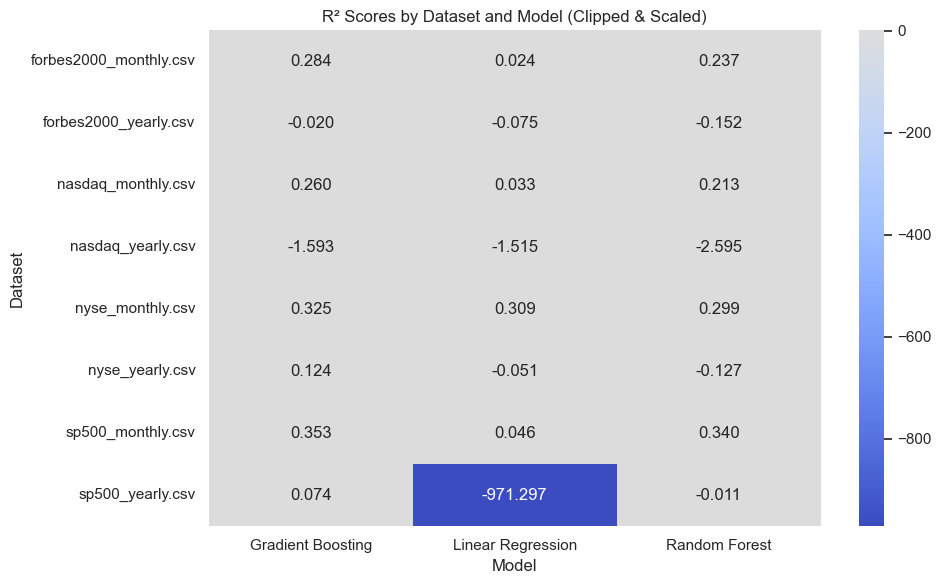

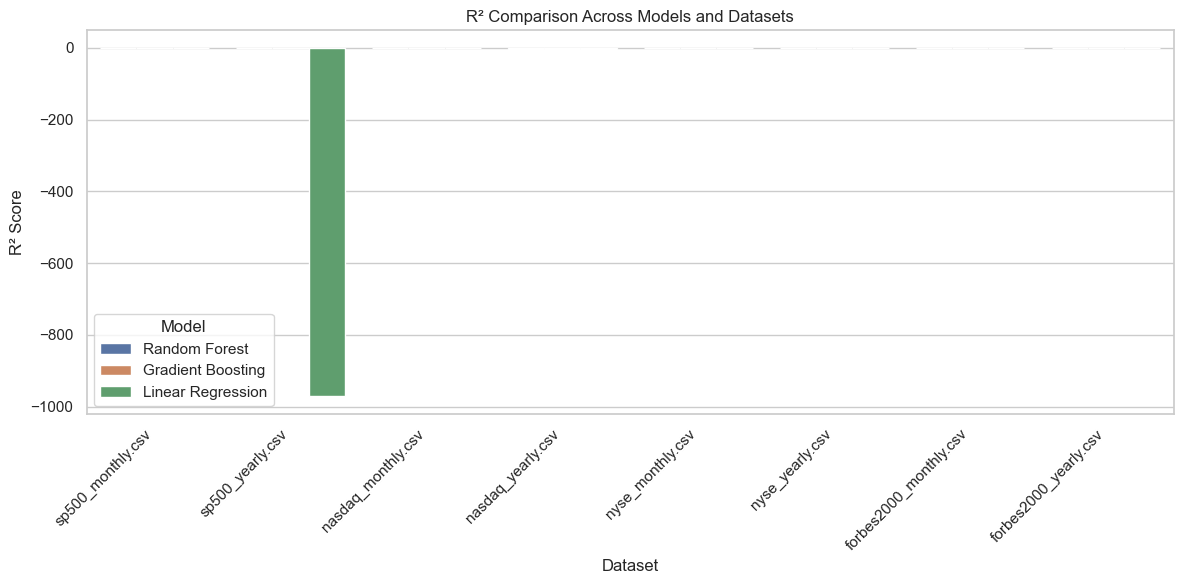

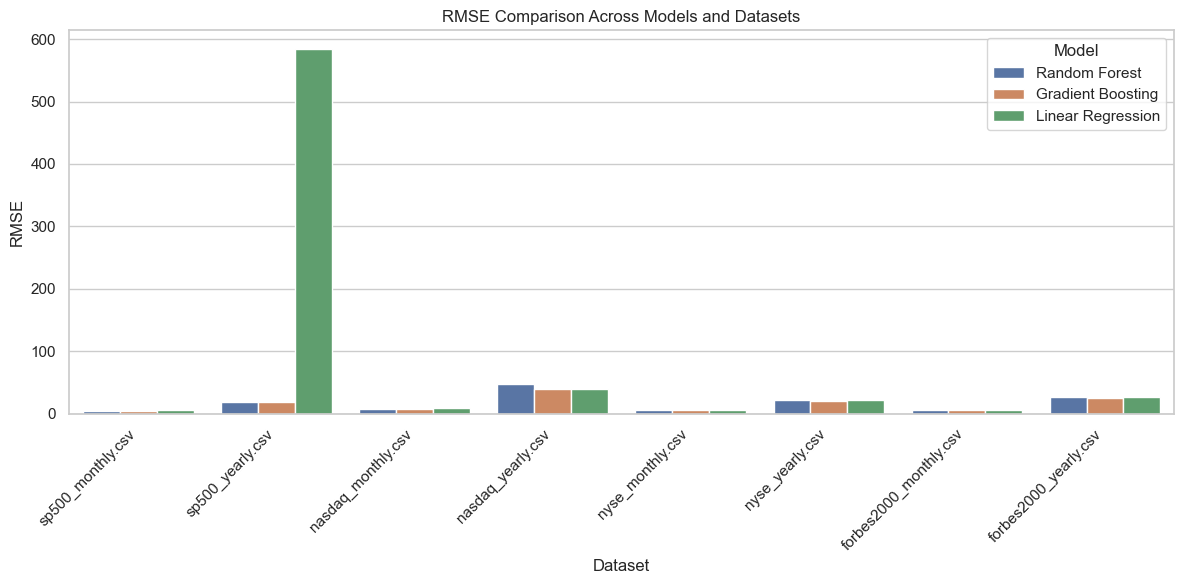

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# ============================================================
# CONFIG
# ============================================================
csv_files = [
    "sp500_monthly.csv",
    "sp500_yearly.csv",
    "nasdaq_monthly.csv",
    "nasdaq_yearly.csv",
    "nyse_monthly.csv",
    "nyse_yearly.csv",
    "forbes2000_monthly.csv",
    "forbes2000_yearly.csv",
]

TARGET_COL = "sector_growth_yoy"
YEAR_COL = "Year"  # change if your yearly files use a different name

# ============================================================
# Helper: signed log transform to handle large magnitude
# ============================================================
def signed_log1p(x):
    """Applies sign(x) * log1p(|x|) elementwise."""
    return np.sign(x) * np.log1p(np.abs(x))

# ============================================================
# Run models on each dataset
# ============================================================
all_results = []

for file in csv_files:
    print(f"\n=== Processing file: {file} ===")
    df = pd.read_csv(file)

    # ------------------ basic checks ------------------
    if TARGET_COL not in df.columns:
        print(f"  [SKIP] '{TARGET_COL}' not found in {file}")
        continue

    has_year = YEAR_COL in df.columns
    if not has_year:
        print(f"  [WARN] '{YEAR_COL}' not found in {file}, using random split instead of time-based.")

    # ------------------ target cleaning ------------------
    df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")
    df = df.dropna(subset=[TARGET_COL])

    # ------------------ numeric features only ------------------
    num_cols = df.select_dtypes(include=["number"]).columns.tolist()
    # Remove target and year from features
    if TARGET_COL in num_cols:
        num_cols.remove(TARGET_COL)
    if has_year and YEAR_COL in num_cols:
        num_cols.remove(YEAR_COL)

    if len(num_cols) == 0:
        print("  [SKIP] No numeric features found.")
        continue

    # ------------------ Build data table ------------------
    if has_year:
        # include Year column for time-based split
        cols_for_data = [YEAR_COL] + num_cols + [TARGET_COL]
    else:
        cols_for_data = num_cols + [TARGET_COL]

    data = df[cols_for_data].dropna()
    print(f"  Using {len(num_cols)} numeric features and {len(data)} rows.")

    # ------------------ time-based or random split ------------------
    if has_year:
        # sort by year and split chronologically
        data = data.sort_values(YEAR_COL)
        n = len(data)
        split_idx = int(0.8 * n)
        train = data.iloc[:split_idx]
        test = data.iloc[split_idx:]

        X_train_raw = train[num_cols]
        y_train = train[TARGET_COL]
        X_test_raw = test[num_cols]
        y_test = test[TARGET_COL]
    else:
        # no Year column: regular random split
        X = data[num_cols]
        y = data[TARGET_COL]
        X_train_raw, X_test_raw, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

    # ------------------ clip outliers in target (based on train only) ------------------
    q_low = y_train.quantile(0.01)
    q_high = y_train.quantile(0.99)
    y_train_clipped = y_train.clip(lower=q_low, upper=q_high)
    y_test_clipped = y_test.clip(lower=q_low, upper=q_high)

    # ------------------ transform & scale features ------------------
    X_train_log = signed_log1p(X_train_raw)
    X_test_log = signed_log1p(X_test_raw)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_log)
    X_test = scaler.transform(X_test_log)

    # ------------------ define models ------------------
    models = {
        "Random Forest": RandomForestRegressor(
            n_estimators=200,
            max_depth=None,
            random_state=42,
            n_jobs=-1
        ),
        "Gradient Boosting": GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ),
        "Linear Regression": LinearRegression()
    }

    # ------------------ train, predict, evaluate ------------------
    for model_name, model in models.items():
        model.fit(X_train, y_train_clipped)
        y_pred = model.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test_clipped, y_pred))
        mae = mean_absolute_error(y_test_clipped, y_pred)
        r2 = r2_score(y_test_clipped, y_pred)

        all_results.append({
            "Dataset": file,
            "Model": model_name,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2,
        })

# ============================================================
# Results summary
# ============================================================
results_df = pd.DataFrame(all_results)
results_sorted = results_df.sort_values(["Dataset", "Model"])

print("\n=== Regression Model Performance Summary (RMSE, MAE, R²) ===")
print(results_sorted.to_string(index=False))

# ============================================================
# Visualisations
# ============================================================

# 1) Heatmap of R²
if not results_df.empty:
    r2_pivot = results_df.pivot(index="Dataset", columns="Model", values="R2")

    plt.figure(figsize=(10, 6))
    sns.heatmap(r2_pivot, annot=True, fmt=".3f", cmap="coolwarm", center=0)
    plt.title("R² Scores by Dataset and Model (Clipped & Scaled)")
    plt.ylabel("Dataset")
    plt.xlabel("Model")
    plt.tight_layout()
    plt.show()

    # 2) Barplot of R²
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=results_df,
        x="Dataset",
        y="R2",
        hue="Model"
    )
    plt.xticks(rotation=45, ha="right")
    plt.title("R² Comparison Across Models and Datasets")
    plt.ylabel("R² Score")
    plt.xlabel("Dataset")
    plt.legend(title="Model")
    plt.tight_layout()
    plt.show()

    # 3) Barplot of RMSE
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=results_df,
        x="Dataset",
        y="RMSE",
        hue="Model"
    )
    plt.xticks(rotation=45, ha="right")
    plt.title("RMSE Comparison Across Models and Datasets")
    plt.ylabel("RMSE")
    plt.xlabel("Dataset")
    plt.legend(title="Model")
    plt.tight_layout()
    plt.show()



=== Processing file: sp500_monthly.csv ===
  [WARN] 'Year' not found in sp500_monthly.csv, using random split instead of time-based.
  Using 3 numeric features and 18380 rows.

=== Processing file: sp500_yearly.csv ===
  Using 3 numeric features and 1553 rows.

=== Processing file: nasdaq_monthly.csv ===
  [WARN] 'Year' not found in nasdaq_monthly.csv, using random split instead of time-based.
  Using 3 numeric features and 18380 rows.

=== Processing file: nasdaq_yearly.csv ===
  Using 3 numeric features and 1553 rows.

=== Processing file: nyse_monthly.csv ===
  [WARN] 'Year' not found in nyse_monthly.csv, using random split instead of time-based.
  Using 3 numeric features and 18380 rows.

=== Processing file: nyse_yearly.csv ===
  Using 3 numeric features and 1553 rows.

=== Processing file: forbes2000_monthly.csv ===
  [WARN] 'Year' not found in forbes2000_monthly.csv, using random split instead of time-based.
  Using 3 numeric features and 18380 rows.

=== Processing file: forbe

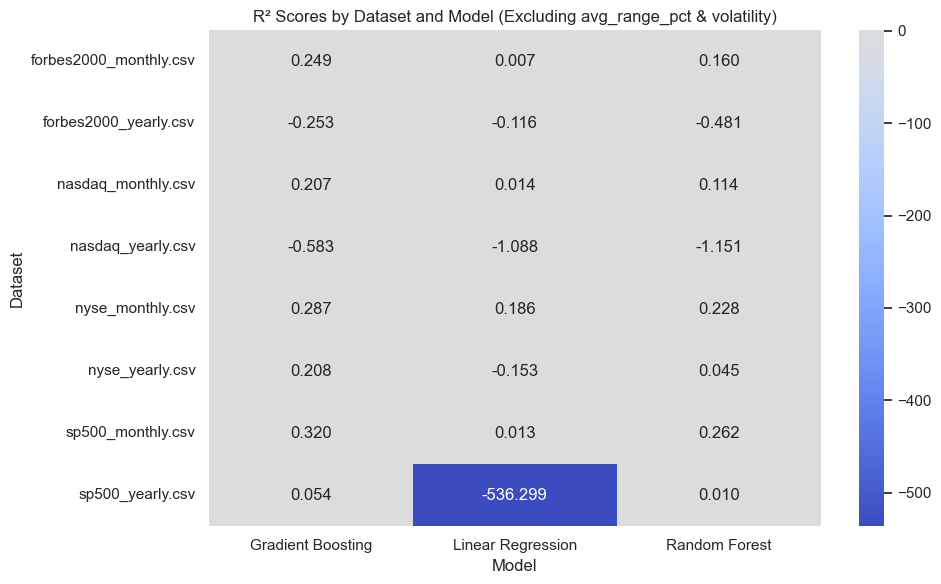

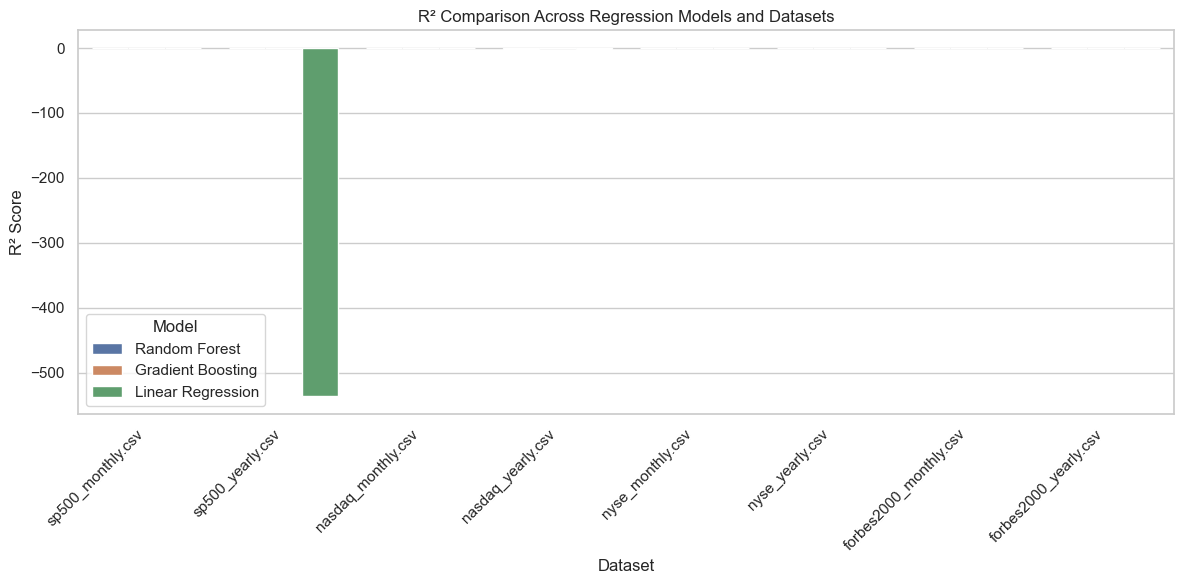

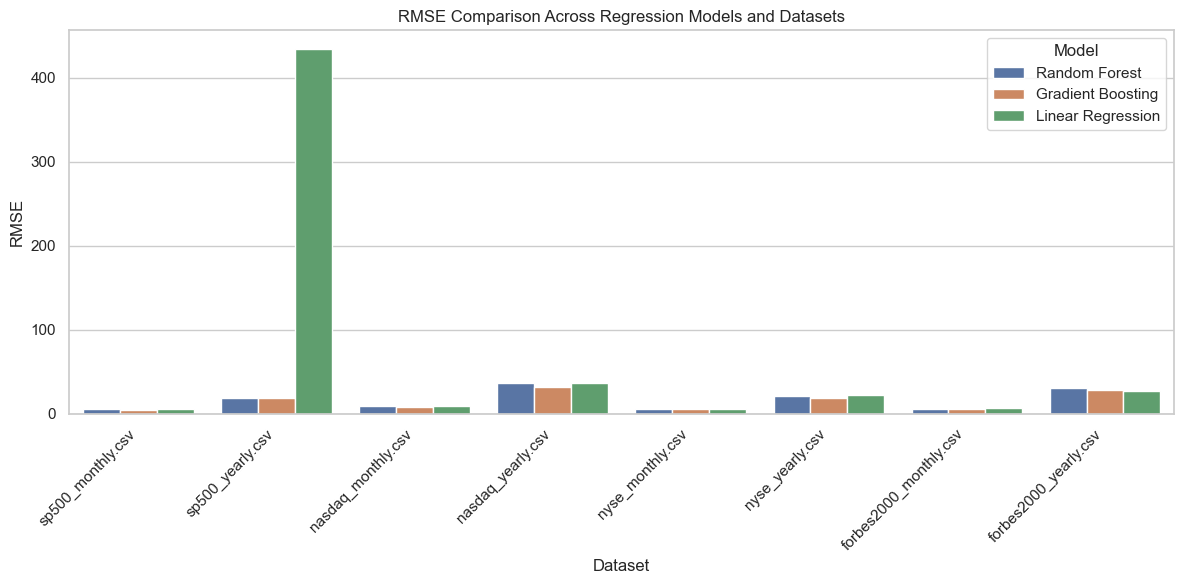

In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# ============================================================
# CONFIG
# ============================================================
csv_files = [
    "sp500_monthly.csv",
    "sp500_yearly.csv",
    "nasdaq_monthly.csv",
    "nasdaq_yearly.csv",
    "nyse_monthly.csv",
    "nyse_yearly.csv",
    "forbes2000_monthly.csv",
    "forbes2000_yearly.csv",
]

TARGET_COL = "sector_growth_yoy"
YEAR_COL = "Year"  # change if your yearly files use a different name

# columns to explicitly exclude from modelling (PCA decision)
EXCLUDE_FEATURES = ["avg_range_pct", "volatility"]

# ============================================================
# Helper: signed log transform to handle large magnitude
# ============================================================
def signed_log1p(x):
    """Applies sign(x) * log1p(|x|) elementwise."""
    return np.sign(x) * np.log1p(np.abs(x))

# ============================================================
# Run models on each dataset
# ============================================================
all_results = []

for file in csv_files:
    print(f"\n=== Processing file: {file} ===")
    df = pd.read_csv(file)

    # ------------------ basic checks ------------------
    if TARGET_COL not in df.columns:
        print(f"  [SKIP] '{TARGET_COL}' not found in {file}")
        continue

    has_year = YEAR_COL in df.columns
    if not has_year:
        print(f"  [WARN] '{YEAR_COL}' not found in {file}, using random split instead of time-based.")

    # ------------------ target cleaning ------------------
    df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")
    df = df.dropna(subset=[TARGET_COL])

    # ------------------ numeric features only ------------------
    num_cols = df.select_dtypes(include=["number"]).columns.tolist()

    # Remove target and year from features
    if TARGET_COL in num_cols:
        num_cols.remove(TARGET_COL)
    if has_year and YEAR_COL in num_cols:
        num_cols.remove(YEAR_COL)

    # Explicitly drop PCA-excluded features if present
    num_cols = [c for c in num_cols if c not in EXCLUDE_FEATURES]

    if len(num_cols) == 0:
        print("  [SKIP] No numeric features found after exclusions.")
        continue

    # ------------------ Build data table ------------------
    if has_year:
        cols_for_data = [YEAR_COL] + num_cols + [TARGET_COL]
    else:
        cols_for_data = num_cols + [TARGET_COL]

    data = df[cols_for_data].dropna()
    print(f"  Using {len(num_cols)} numeric features and {len(data)} rows.")

    # ------------------ time-based or random split ------------------
    if has_year:
        data = data.sort_values(YEAR_COL)
        n = len(data)
        split_idx = int(0.8 * n)
        train = data.iloc[:split_idx]
        test = data.iloc[split_idx:]

        X_train_raw = train[num_cols]
        y_train = train[TARGET_COL]
        X_test_raw = test[num_cols]
        y_test = test[TARGET_COL]
    else:
        X = data[num_cols]
        y = data[TARGET_COL]
        X_train_raw, X_test_raw, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

    # ------------------ clip outliers in target (based on train only) ------------------
    q_low = y_train.quantile(0.01)
    q_high = y_train.quantile(0.99)
    y_train_clipped = y_train.clip(lower=q_low, upper=q_high)
    y_test_clipped = y_test.clip(lower=q_low, upper=q_high)

    # ------------------ transform & scale features ------------------
    X_train_log = signed_log1p(X_train_raw)
    X_test_log = signed_log1p(X_test_raw)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_log)
    X_test = scaler.transform(X_test_log)

    # ------------------ define models ------------------
    models = {
        "Random Forest": RandomForestRegressor(
            n_estimators=200,
            max_depth=None,
            random_state=42,
            n_jobs=-1
        ),
        "Gradient Boosting": GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ),
        "Linear Regression": LinearRegression()
    }

    # ------------------ train, predict, evaluate ------------------
    for model_name, model in models.items():
        model.fit(X_train, y_train_clipped)
        y_pred = model.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test_clipped, y_pred))
        mae = mean_absolute_error(y_test_clipped, y_pred)
        r2 = r2_score(y_test_clipped, y_pred)

        all_results.append({
            "Dataset": file,
            "Model": model_name,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2,
        })

# ============================================================
# Results summary
# ============================================================
results_df = pd.DataFrame(all_results)
results_sorted = results_df.sort_values(["Dataset", "Model"])

print("\n=== Regression Model Performance Summary (RMSE, MAE, R²) ===")
print(results_sorted.to_string(index=False))

# Also print a compact "best model per dataset" summary (by highest R²)
print("\n=== Best Regression Model Per Dataset (by R²) ===")
best_per_dataset = (
    results_df.sort_values("R2", ascending=False)
              .groupby("Dataset")
              .head(1)
              .reset_index(drop=True)
)
# Round for nicer printing
best_display = best_per_dataset.copy()
best_display["RMSE"] = best_display["RMSE"].round(3)
best_display["MAE"] = best_display["MAE"].round(3)
best_display["R2"] = best_display["R2"].round(3)
print(best_display.to_string(index=False))

# You can also export this for a table in the paper if you like:
# best_display.to_csv("regression_best_models_summary.csv", index=False)

# ============================================================
# Visualisations
# ============================================================
if not results_df.empty:
    # 1) Heatmap of R²
    r2_pivot = results_df.pivot(index="Dataset", columns="Model", values="R2")

    plt.figure(figsize=(10, 6))
    sns.heatmap(r2_pivot, annot=True, fmt=".3f", cmap="coolwarm", center=0)
    plt.title("R² Scores by Dataset and Model (Excluding avg_range_pct & volatility)")
    plt.ylabel("Dataset")
    plt.xlabel("Model")
    plt.tight_layout()
    plt.show()

    # 2) Barplot of R²
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=results_df,
        x="Dataset",
        y="R2",
        hue="Model"
    )
    plt.xticks(rotation=45, ha="right")
    plt.title("R² Comparison Across Regression Models and Datasets")
    plt.ylabel("R² Score")
    plt.xlabel("Dataset")
    plt.legend(title="Model")
    plt.tight_layout()
    plt.show()

    # 3) Barplot of RMSE
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=results_df,
        x="Dataset",
        y="RMSE",
        hue="Model"
    )
    plt.xticks(rotation=45, ha="right")
    plt.title("RMSE Comparison Across Regression Models and Datasets")
    plt.ylabel("RMSE")
    plt.xlabel("Dataset")
    plt.legend(title="Model")
    plt.tight_layout()
    plt.show()


Using features: ['avg_return', 'avg_adj_close', 'avg_volume']

=== Regression Performance by Sector for sp500_monthly.csv ===
                                               MAE                    \
Model                            Gradient Boosting Linear Regression   
Sector                                                                 
Aerospace & Defense                          2.902             2.904   
Airlines                                     4.142             4.044   
Auto Components                              4.452             4.618   
Banking                                      6.291             4.645   
Beverages                                    2.417             2.646   
Biotechnology                                4.473             3.831   
Building                                     4.382             4.133   
Chemicals                                    3.210             2.901   
Commercial Services & Supplies               3.476             3.376   
Communicat

In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ============================================================
# CONFIG
# ============================================================
csv_files = [
    "sp500_monthly.csv",
    "sp500_yearly.csv",
    "nasdaq_monthly.csv",
    "nasdaq_yearly.csv",
    "nyse_monthly.csv",
    "nyse_yearly.csv",
    "forbes2000_monthly.csv",
    "forbes2000_yearly.csv",
]

TARGET_COL = "sector_growth_yoy"
SECTOR_COL = "sector"        # change if your sector column name differs
YEAR_COL = "Year"            # only used for yearly time-based splits, if present
EXCLUDE_FEATURES = ["avg_range_pct", "volatility"]   # from PCA decision
MIN_SAMPLES_PER_SECTOR = 30  # skip tiny sectors

# ============================================================
# Helper: signed log transform
# ============================================================
def signed_log1p(x):
    """Applies sign(x) * log1p(|x|) elementwise."""
    return np.sign(x) * np.log1p(np.abs(x))

# ============================================================
# Collect results across all datasets / sectors / models
# ============================================================
all_rows = []

for file in csv_files:
    print(f"\n=== Processing file: {file} ===")
    df = pd.read_csv(file)

    # sanity checks
    if TARGET_COL not in df.columns:
        print(f"  [SKIP] '{TARGET_COL}' not found in {file}")
        continue
    if SECTOR_COL not in df.columns:
        print(f"  [SKIP] sector column '{SECTOR_COL}' not found in {file}")
        continue

    # make sure target is numeric
    df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")
    df = df.dropna(subset=[TARGET_COL, SECTOR_COL])

    # numeric feature columns
    num_cols = df.select_dtypes(include=["number"]).columns.tolist()
    if TARGET_COL in num_cols:
        num_cols.remove(TARGET_COL)

    # drop excluded features
    num_cols = [c for c in num_cols if c not in EXCLUDE_FEATURES]

    if not num_cols:
        print("  [SKIP] no usable numeric features after exclusions.")
        continue

    print(f"  Using features: {num_cols}")

    # flag if we have a Year column for time-based split (usually yearly files)
    has_year = YEAR_COL in df.columns

    # models to compare
    model_defs = {
        "Linear Regression": LinearRegression(),
        "Random Forest": RandomForestRegressor(
            n_estimators=200,
            max_depth=None,
            random_state=42,
            n_jobs=-1
        ),
        "Gradient Boosting": GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ),
    }

    # --------------------------------------------------------
    # PER-SECTOR LOOP
    # --------------------------------------------------------
    for sector_name, sector_df in df.groupby(SECTOR_COL):
        if len(sector_df) < MIN_SAMPLES_PER_SECTOR:
            continue

        # Build data table for this sector
        sector_data = sector_df.copy()

        # if yearly and Year exists, sort chronologically & split by time
        if has_year:
            sector_data = sector_data.dropna(subset=num_cols + [TARGET_COL, YEAR_COL])
            sector_data = sector_data.sort_values(YEAR_COL)
        else:
            sector_data = sector_data.dropna(subset=num_cols + [TARGET_COL])

        if len(sector_data) < MIN_SAMPLES_PER_SECTOR:
            continue

        X_raw = sector_data[num_cols]
        y = sector_data[TARGET_COL]
        n_samples = len(sector_data)

        if has_year:
            # chronological 80/20 split
            n = len(sector_data)
            split_idx = int(0.8 * n)
            train = sector_data.iloc[:split_idx]
            test = sector_data.iloc[split_idx:]

            X_train_raw = train[num_cols]
            y_train = train[TARGET_COL]
            X_test_raw = test[num_cols]
            y_test = test[TARGET_COL]
        else:
            # random 80/20 split for monthly datasets without Year
            X_train_raw, X_test_raw, y_train, y_test = train_test_split(
                X_raw, y, test_size=0.2, random_state=42
            )

        # clip target outliers based on train only
        q_low = y_train.quantile(0.01)
        q_high = y_train.quantile(0.99)
        y_train_clipped = y_train.clip(lower=q_low, upper=q_high)
        y_test_clipped = y_test.clip(lower=q_low, upper=q_high)

        # transform & scale features
        X_train_log = signed_log1p(X_train_raw)
        X_test_log = signed_log1p(X_test_raw)

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train_log)
        X_test = scaler.transform(X_test_log)

        # fit/evaluate all models
        for model_name, model in model_defs.items():
            model.fit(X_train, y_train_clipped)
            y_pred = model.predict(X_test)

            mae = mean_absolute_error(y_test_clipped, y_pred)
            rmse = np.sqrt(mean_squared_error(y_test_clipped, y_pred))
            r2 = r2_score(y_test_clipped, y_pred)

            all_rows.append({
                "Dataset": file,
                "Sector": sector_name,
                "Model": model_name,
                "MAE": mae,
                "RMSE": rmse,
                "R2": r2,
                "n_samples": n_samples,
            })

# ============================================================
# Aggregate & pick best (dataset, model) by mean R²
# ============================================================
results_df = pd.DataFrame(all_rows)
if results_df.empty:
    raise RuntimeError("No results collected – check file paths / column names.")

# mean R² per (Dataset, Model)
summary = (
    results_df
    .groupby(["Dataset", "Model"], as_index=False)["R2"]
    .mean()
    .rename(columns={"R2": "mean_R2"})
)

print("\n=== Mean R² by Dataset and Model ===")
print(summary.sort_values("mean_R2", ascending=False).to_string(index=False))

best_row = summary.loc[summary["mean_R2"].idxmax()]
best_dataset = best_row["Dataset"]
best_model = best_row["Model"]

print(f"\nBest overall regression configuration by mean R²:")
print(f"  Dataset: {best_dataset}")
print(f"  Model:   {best_model}")
print(f"  mean R²: {best_row['mean_R2']:.3f}")

# ============================================================
# Extract 9 sectors for the best dataset+model and build table
# ============================================================
best_results = results_df[
    (results_df["Dataset"] == best_dataset) &
    (results_df["Model"] == best_model)
].copy()

# pick 9 sectors with most samples (you can change this to top-9 R² if preferred)
best_results = best_results.sort_values("n_samples", ascending=False)
top9 = best_results.head(9).copy()

# sort nicely by sector name and round metrics
top9 = top9.sort_values("Sector")
top9_display = top9[["Sector", "MAE", "RMSE", "R2"]].copy()
top9_display[["MAE", "RMSE", "R2"]] = top9_display[["MAE", "RMSE", "R2"]].round(3)

print(f"\n=== Regression Performance for {best_model} on {best_dataset} (Top 9 Sectors) ===")
print(top9_display.to_string(index=False))

# optional: save as CSV to paste into the paper
top9_display.to_csv("regression_best_dataset_top9_sectors.csv", index=False)



=== Processing file: sp500_monthly.csv ===
  Using features: ['avg_return', 'avg_adj_close', 'avg_volume']

=== Processing file: sp500_yearly.csv ===
  Using features: ['Year', 'avg_return', 'avg_adj_close', 'avg_volume']

=== Processing file: nasdaq_monthly.csv ===
  Using features: ['avg_return', 'avg_adj_close', 'avg_volume']

=== Processing file: nasdaq_yearly.csv ===
  Using features: ['Year', 'avg_return', 'avg_adj_close', 'avg_volume']

=== Processing file: nyse_monthly.csv ===
  Using features: ['avg_return', 'avg_adj_close', 'avg_volume']

=== Processing file: nyse_yearly.csv ===
  Using features: ['Year', 'avg_return', 'avg_adj_close', 'avg_volume']

=== Processing file: forbes2000_monthly.csv ===
  Using features: ['avg_return', 'avg_adj_close', 'avg_volume']

=== Processing file: forbes2000_yearly.csv ===
  Using features: ['Year', 'avg_return', 'avg_adj_close', 'avg_volume']

=== Mean R² by Dataset and Model ===
               Dataset             Model       mean_R2
     

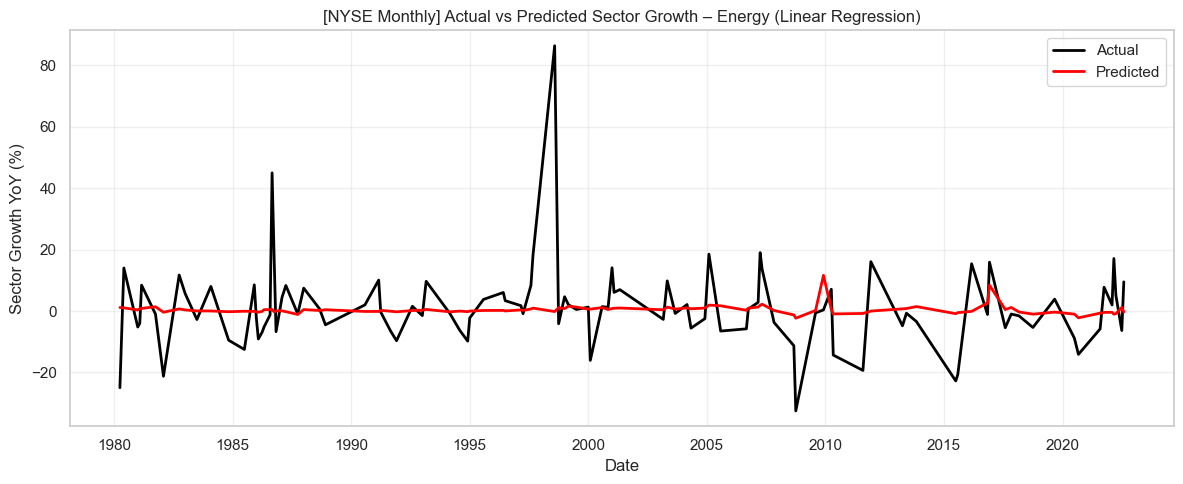

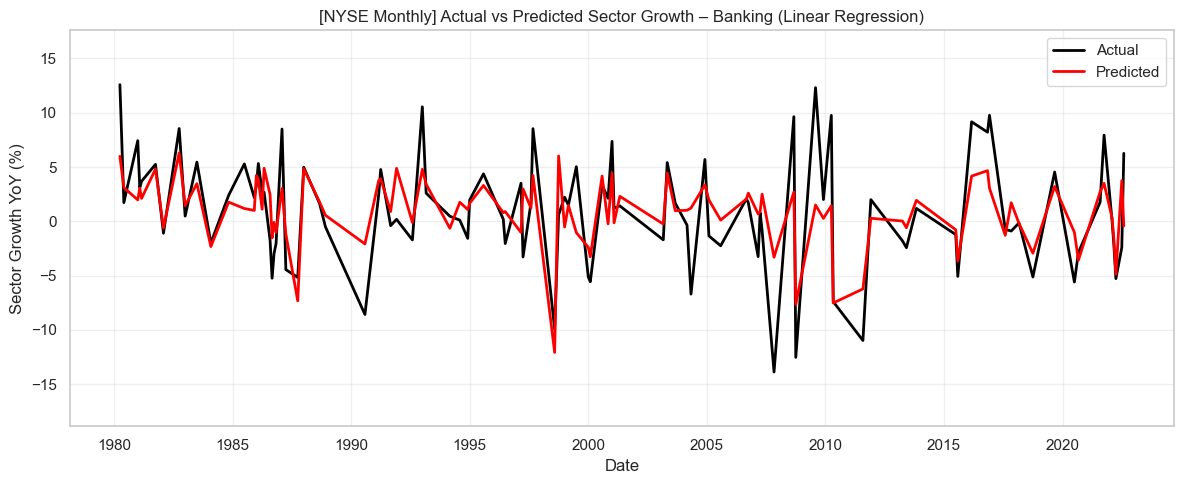

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# =====================================================
# CONFIG – use your best model + dataset here
# =====================================================
CSV_FILE = "nyse_monthly.csv"
TARGET_COL = "sector_growth_yoy"
SECTOR_COL = "sector"
DATE_COL = "YearMonth"  # or change to 'Date' or 'Year' depending on file
EXCLUDE_FEATURES = ["avg_range_pct", "volatility"]
SELECTED_SECTORS = ["Energy", "Banking"]  # Change sectors here

# =====================================================
# Load and clean dataset
# =====================================================
df = pd.read_csv(CSV_FILE)

# Drop rows with missing target or sector
df = df.dropna(subset=[TARGET_COL, SECTOR_COL])

# Extract datetime
if "YearMonth" in df.columns:
    df["Date"] = pd.to_datetime(df["YearMonth"])
elif "Year" in df.columns:
    df["Date"] = pd.to_datetime(df["Year"].astype(str) + "-01-01")
else:
    raise ValueError("No valid date column found in dataset.")

# Keep only numeric features (excluding target)
num_cols = df.select_dtypes(include=["number"]).columns.tolist()
for col in [TARGET_COL] + EXCLUDE_FEATURES:
    if col in num_cols:
        num_cols.remove(col)

# =====================================================
# Build regression_df with predictions per sector
# =====================================================
all_rows = []

for sector_name, group in df.groupby(SECTOR_COL):
    if sector_name not in SELECTED_SECTORS:
        continue

    group = group.sort_values("Date")
    X_raw = group[num_cols]
    y = group[TARGET_COL]
    dates = group["Date"]

    # Skip sectors with too little data
    if len(group) < 10:
        continue

    # Train/test split
    X_train_raw, X_test_raw, y_train, y_test, dates_train, dates_test = train_test_split(
        X_raw, y, dates, test_size=0.2, random_state=42
    )

    # Transform features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test = scaler.transform(X_test_raw)

    # Train model
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Store results
    for d, yt, yp in zip(dates_test, y_test, y_pred):
        all_rows.append({
            "Date": d,
            "Sector": sector_name,
            "Actual": yt,
            "Predicted": yp
        })

# Create DataFrame
regression_df = pd.DataFrame(all_rows)

# =====================================================
# Plotting function – Actual vs Predicted
# =====================================================
def plot_regression_sector(regression_df, sector_name, dataset_name="NYSE Monthly", model_name="Linear Regression", save=False):
    df = regression_df[regression_df["Sector"] == sector_name].copy()
    if df.empty:
        print(f"[WARNING] No data found for sector: {sector_name}")
        return

    df = df.sort_values("Date")
    actual = df["Actual"].values
    predicted = df["Predicted"].values
    dates = df["Date"].values

    plt.figure(figsize=(12, 5))
    plt.plot(dates, actual, label="Actual", color="black", linewidth=2)
    plt.plot(dates, predicted, label="Predicted", color="red", linewidth=2)

    plt.title(f"[{dataset_name}] Actual vs Predicted Sector Growth – {sector_name} ({model_name})")
    plt.xlabel("Date")
    plt.ylabel("Sector Growth YoY (%)")
    plt.ylim(min(actual.min(), predicted.min()) - 5, max(actual.max(), predicted.max()) + 5)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if save:
        filename = f"{sector_name.lower().replace(' ', '_')}_regression_plot.png"
        plt.savefig(filename, dpi=300)
        print(f"Saved plot as: {filename}")
    else:
        plt.show()

# =====================================================
# Plot selected sectors
# =====================================================
for sector in SELECTED_SECTORS:
    plot_regression_sector(regression_df, sector)
